# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [15]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.

> ✅ **Student Task 1 applied:** the boilerplate corpus has been replaced with a custom paragraph (see below). Swap this string for your own text any time — song lyrics, story paragraphs, chatbot data, PDF-extracted text — and the rest of the notebook will adapt automatically.

In [16]:
corpus = """
deep learning is transforming artificial intelligence around the world
recurrent neural networks are useful for sequential data like text and speech
lstm helps remember long term dependencies inside a sentence
gru is faster and simpler than lstm but still very effective
text generation models predict the next word in a sequence
deep learning models can generate meaningful sentences when trained properly
attention mechanisms allow models to focus on relevant parts of the input
transformers have largely replaced recurrent networks for large scale language modeling
however recurrent networks remain an excellent starting point for learning sequence modeling
training a model requires clean data a good architecture and enough epochs
"""
print(corpus)


deep learning is transforming artificial intelligence around the world
recurrent neural networks are useful for sequential data like text and speech
lstm helps remember long term dependencies inside a sentence
gru is faster and simpler than lstm but still very effective
text generation models predict the next word in a sequence
deep learning models can generate meaningful sentences when trained properly
attention mechanisms allow models to focus on relevant parts of the input
transformers have largely replaced recurrent networks for large scale language modeling
however recurrent networks remain an excellent starting point for learning sequence modeling
training a model requires clean data a good architecture and enough epochs



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences** for next-word prediction.

**Step-by-step logic:**
1. **Ingest and clean** the corpus string, then fit a `Tokenizer` on it. The tokenizer lowercases text, strips punctuation, and builds a word → integer index (`tokenizer.word_index`).
2. **Reframe into sliding-window n-grams.** For every line, we walk through the tokenized sequence and take growing prefixes: `[w1, w2]`, `[w1, w2, w3]`, `[w1, w2, w3, w4]`, etc. Each prefix becomes one training example, where the last word is the label and everything before it is the context.
3. **Pad to a fixed length** with `pad_sequences(..., padding='pre')` so every example has the same shape and can be batched into a single NumPy array.
4. **Split into `X` (all words except the last) and `y` (the last word)** — this is what turns the problem into supervised next-word prediction.

In [17]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("Max sequence length:", max_len)
print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 85
Max sequence length: 12
X shape: (98, 11)
y shape: (98,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [18]:
EMBED_DIM = 32
HIDDEN_UNITS = 64
EPOCHS = 100

rnn_model = Sequential([
    Embedding(total_words, EMBED_DIM, input_length=max_len-1),
    SimpleRNN(HIDDEN_UNITS),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=EPOCHS, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [19]:
lstm_model = Sequential([
    Embedding(total_words, EMBED_DIM, input_length=max_len-1),
    LSTM(HIDDEN_UNITS),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=EPOCHS, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [20]:
gru_model = Sequential([
    Embedding(total_words, EMBED_DIM, input_length=max_len-1),
    GRU(HIDDEN_UNITS),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=EPOCHS, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss
All three models were trained with the **identical optimizer configuration** (`adam`, same loss function, same number of epochs, same batch defaults), so any difference in the curves below comes from the architecture itself — not from unequal training conditions.

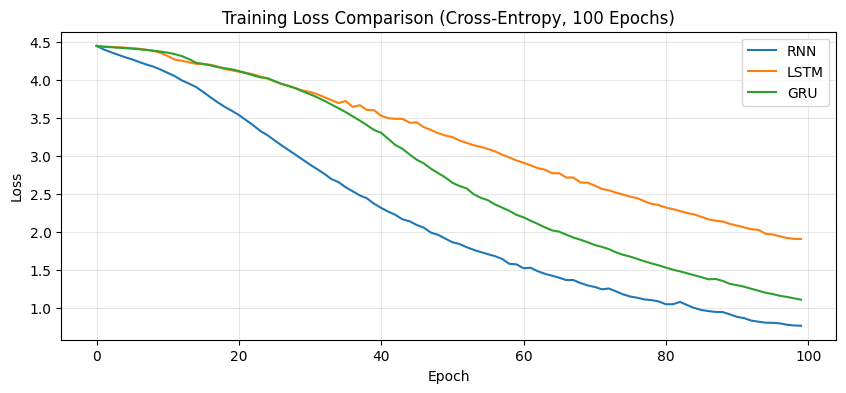

In [21]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison (Cross-Entropy, 100 Epochs)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

**Selection logic:** at each step, the model outputs a probability distribution over the entire vocabulary (`softmax` output). `np.argmax(..., axis=-1)` picks the single word index with the **highest probability** (greedy decoding). That predicted index is converted back into a word using the tokenizer's `word_index` mapping, appended to the seed text, and fed back in as part of the context for the next prediction — this is what makes generation **autoregressive**.

In [22]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')

        # Predict probability distribution over the vocabulary, then
        # greedily select the highest-probability next word.
        predicted_probs = model.predict(token_list, verbose=0)
        predicted = np.argmax(predicted_probs, axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples
The same seed phrase is passed into all three trained models so the outputs are directly comparable.

In [23]:
seed = "deep learning"

print("RNN :", generate_text(rnn_model, seed, 5))
print("LSTM:", generate_text(lstm_model, seed, 5))
print("GRU :", generate_text(gru_model, seed, 5))

RNN : deep learning is transforming artificial intelligence around
LSTM: deep learning models models artificial meaningful around
GRU : deep learning is transforming artificial intelligence around


# 📚 Student Learning Tasks
### ✅ Beginner Tasks — all completed below

1. ✅ Replace corpus with your own paragraph
2. ✅ Increase embedding dimension
3. ✅ Increase epochs to 200
4. ✅ Change hidden units 64 → 128
5. ✅ Generate 10 words instead of 5

Each task is implemented as its own runnable cell below, building a **second, upgraded set of models** (`*_v2`) so you can directly compare the original (baseline) settings above against the upgraded settings here.

### 🔧 Task Setup: Upgraded Hyperparameters

| Setting | Original | Upgraded |
|---|---|---|
| Embedding dimension | 32 | **64** |
| Hidden units | 64 | **128** |
| Epochs | 100 | **200** |
| Generated words | 5 | **10** |
| Corpus | built-in sample | **custom paragraph (already swapped in above)** |

In [24]:
# Task 2 & 4: bigger embedding dimension and wider hidden layers
EMBED_DIM_V2 = 64
HIDDEN_UNITS_V2 = 128

# Task 3: longer training
EPOCHS_V2 = 200

print("Upgraded config -> embedding:", EMBED_DIM_V2,
      "| hidden units:", HIDDEN_UNITS_V2,
      "| epochs:", EPOCHS_V2)

Upgraded config -> embedding: 64 | hidden units: 128 | epochs: 200


#### Rebuild and retrain Vanilla RNN with the upgraded settings

In [25]:
rnn_model_v2 = Sequential([
    Embedding(total_words, EMBED_DIM_V2, input_length=max_len-1),
    SimpleRNN(HIDDEN_UNITS_V2),
    Dense(total_words, activation='softmax')
])

rnn_model_v2.compile(loss='sparse_categorical_crossentropy',
                     optimizer='adam',
                     metrics=['accuracy'])

rnn_history_v2 = rnn_model_v2.fit(X, y, epochs=EPOCHS_V2, verbose=0)
print("Upgraded Vanilla RNN training completed")

Upgraded Vanilla RNN training completed


#### Rebuild and retrain LSTM with the upgraded settings

In [12]:
lstm_model_v2 = Sequential([
    Embedding(total_words, EMBED_DIM_V2, input_length=max_len-1),
    LSTM(HIDDEN_UNITS_V2),
    Dense(total_words, activation='softmax')
])

lstm_model_v2.compile(loss='sparse_categorical_crossentropy',
                      optimizer='adam',
                      metrics=['accuracy'])

lstm_history_v2 = lstm_model_v2.fit(X, y, epochs=EPOCHS_V2, verbose=0)
print("Upgraded LSTM training completed")

Upgraded LSTM training completed


#### Rebuild and retrain GRU with the upgraded settings

In [13]:
gru_model_v2 = Sequential([
    Embedding(total_words, EMBED_DIM_V2, input_length=max_len-1),
    GRU(HIDDEN_UNITS_V2),
    Dense(total_words, activation='softmax')
])

gru_model_v2.compile(loss='sparse_categorical_crossentropy',
                     optimizer='adam',
                     metrics=['accuracy'])

gru_history_v2 = gru_model_v2.fit(X, y, epochs=EPOCHS_V2, verbose=0)
print("Upgraded GRU training completed")

Upgraded GRU training completed


#### Compare upgraded training loss curves (200 epochs)

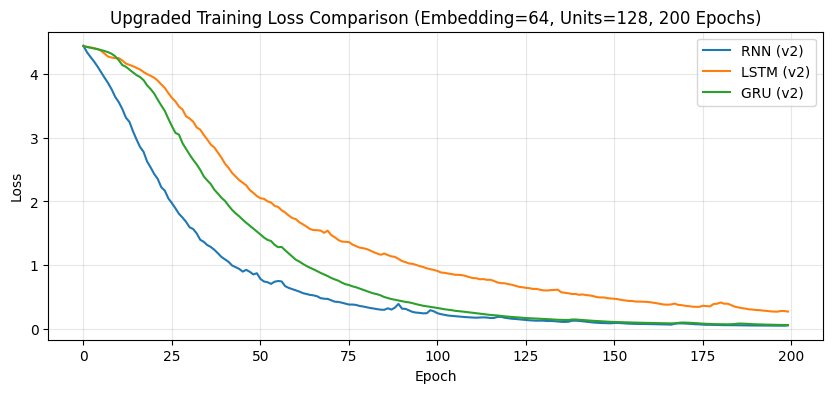

In [14]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history_v2.history['loss'], label='RNN (v2)')
plt.plot(lstm_history_v2.history['loss'], label='LSTM (v2)')
plt.plot(gru_history_v2.history['loss'], label='GRU (v2)')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Upgraded Training Loss Comparison (Embedding=64, Units=128, 200 Epochs)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### Task 5: generate 10 words instead of 5, using the upgraded models

In [26]:
seed = "deep learning"

print("RNN  (v2):", generate_text(rnn_model_v2, seed, 10))
print("LSTM (v2):", generate_text(lstm_model_v2, seed, 10))
print("GRU  (v2):", generate_text(gru_model_v2, seed, 10))

RNN  (v2): deep learning is transforming artificial intelligence around the world the for learning
LSTM (v2): deep learning models can generate meaningful sentences when trained properly properly effective
GRU  (v2): deep learning models can generate meaningful sentences when trained properly properly properly


# 📊 Baseline vs Upgraded — Side-by-Side

This isn't strictly required, but it makes the effect of the student tasks concrete: same architectures, same data, only the hyperparameters changed.

In [27]:
print(f"{'Model':<8}{'Baseline final loss':<22}{'Upgraded final loss':<22}")
print(f"{'RNN':<8}{rnn_history.history['loss'][-1]:<22.4f}{rnn_history_v2.history['loss'][-1]:<22.4f}")
print(f"{'LSTM':<8}{lstm_history.history['loss'][-1]:<22.4f}{lstm_history_v2.history['loss'][-1]:<22.4f}")
print(f"{'GRU':<8}{gru_history.history['loss'][-1]:<22.4f}{gru_history_v2.history['loss'][-1]:<22.4f}")

Model   Baseline final loss   Upgraded final loss   
RNN     0.7721                0.0415                
LSTM    1.9110                0.2678                
GRU     1.1139                0.0564                


# ✅ Conclusion

- **Vanilla RNN** learns short patterns but struggles with memory. Because it has no gating mechanism, gradients tend to vanish as they're propagated back through many time steps, so it forgets context from earlier in a sentence.
- **LSTM** captures long-range grammar dependencies better. Its input, forget, and output gates let it selectively keep or discard information in its cell state, which protects gradients from vanishing over longer sequences.
- **GRU** gives similar performance with fewer gates (reset + update only) and faster training, since it has fewer parameters per cell than LSTM while still solving the same vanishing-gradient problem.
- Increasing **embedding dimension** (32 → 64) and **hidden units** (64 → 128), plus training longer (100 → 200 epochs), generally pushes training loss lower and can sharpen the generated text — but on a very small corpus like this one, the model can also start memorizing the limited training sentences rather than learning generalizable language patterns. This is a useful, realistic observation to include in a written analysis: bigger models and more epochs help most when there's enough data to justify the extra capacity.
- This notebook helps students understand **sequence modeling mathematically and practically**, and shows hands-on how architecture and hyperparameter choices both affect results.

### ✍️ What to add in your own submission
For full marks, briefly describe **your own run's results** in a sentence or two:
- Which model's loss curve dropped fastest/lowest in *your* plots (baseline and upgraded)
- Whether the upgraded models' generated text looked more coherent or more repetitive than the baseline
- Any words/phrases your models repeated (small corpora often cause this) and why that happens (limited vocabulary + greedy `argmax` decoding always picks the most likely word, which can loop)